In [11]:
import logging

import shap

from darts import set_option

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)
shap.initjs()
set_option("plotting.use_darts_style", True)

In [12]:
import pandas as pd

from darts import concatenate
from darts.explainability import TorchExplainer
from darts.models import TiDEModel
from darts.utils.timeseries_generation import linear_timeseries

GLOBAL = False

series = concatenate(
    [
        linear_timeseries(length=100, start_value=0, end_value=1),
        linear_timeseries(length=100, start_value=0, end_value=-1),
    ],
    axis=1,
).astype("float32")
series = series.with_static_covariates(
    pd.DataFrame({"s1": [1]})
    if GLOBAL
    else pd.DataFrame({"s1": [1] * series.n_components})
)
series

,linear,linear_1
time,,
2000-01-01,0.000000,0.000000
2000-01-02,0.010101,-0.010101
2000-01-03,0.020202,-0.020202
2000-01-04,0.030303,-0.030303
2000-01-05,0.040404,-0.040404
...,...,...
2000-04-05,0.959596,-0.959596
2000-04-06,0.969697,-0.969697
2000-04-07,0.979798,-0.979798


In [13]:
train, val = series[:-36], series[-36:]
model = TiDEModel(
    input_chunk_length=13,
    output_chunk_length=12,
    n_epochs=100,
    add_encoders={
        "cyclic": {"future": ["month"]},
    },
    use_static_covariates=True,
)
model.fit(train)

INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 40 samples.
INFO:darts.models.forecasting.torch_forecasting_model:Time series values are 32-bits; casting model to float32.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                  | Type             | Params | Mode 
-------------------------------------------------------------------
0 | criterion             | MSELoss          | 0      | eval 
1 | train_criterion       | MSELoss          | 0      | eval 
2 | val_criterion         | MSELoss          | 0      | eval 
3 | train_metrics         | MetricCollection | 0      | train
4 | val_metrics           | MetricCollection | 0      | train
5 | future_cov_projection | _ResidualBlock   | 912    | train
6 | e

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


TiDEModel(output_chunk_shift=0, num_encoder_layers=1, num_decoder_layers=1, decoder_output_dim=16, hidden_size=128, temporal_width_past=4, temporal_width_future=4, temporal_hidden_size_past=None, temporal_hidden_size_future=None, temporal_decoder_hidden=32, use_layer_norm=False, dropout=0.1, use_static_covariates=True, input_chunk_length=13, output_chunk_length=12, n_epochs=100, add_encoders={'cyclic': {'future': ['month']}})

In [14]:
pred = model.predict(n=36)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/Users/engs2902/Documents/code/darts/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/Users/engs2902/Documents/code/darts/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning:

'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.



Predicting: |          | 0/? [00:00<?, ?it/s]

In [15]:
fig = series[-72:].plotly(label="actual")
pred.plotly(label="predicted", fig=fig)

In [16]:
shap_explain = TorchExplainer(
    model,
    batch_size=1024,
    shap_method="kernel",
)

results = shap_explain.explain(series[-72:-36])

/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




  0%|          | 0/24 [00:00<?, ?it/s]

INFO:shap:num_full_subsets = 1
INFO:shap:remaining_weight_vector = array([0.13118783, 0.08865661, 0.06741597, 0.05469239, 0.04622809,
       0.04019834, 0.03569081, 0.03219867, 0.02941788, 0.02715496,
       0.02528099, 0.02370671, 0.02236843, 0.02121945, 0.02022479,
       0.01935773, 0.01859751, 0.01792779, 0.01733553, 0.01681022,
       0.01634326, 0.01592764, 0.01555753, 0.01522808, 0.01493523,
       0.01467558, 0.01444628, 0.0142449 , 0.01406942, 0.01391814,
       0.01378963, 0.01368273, 0.0135965 , 0.01353017, 0.01348319,
       0.01345516, 0.01344584])
INFO:shap:num_paired_subset_sizes = 37
INFO:shap:weight_left = np.float64(0.7932544769825256)
INFO:shap:np.sum(w_aug) = np.float64(76.00000000000001)
INFO:shap:np.sum(self.kernelWeights) = np.float64(0.9999999999999999)
INFO:shap:phi = array([0.01473513, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.01028478, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.01104

In [18]:
results.get_explanation(horizon=1, component="linear").components

Index(['linear_target_lag-13', 'linear_1_target_lag-13',
       'darts_enc_fc_cyc_month_sin_futcov_lag-13',
       'darts_enc_fc_cyc_month_cos_futcov_lag-13', 'linear_target_lag-12',
       'linear_1_target_lag-12', 'darts_enc_fc_cyc_month_sin_futcov_lag-12',
       'darts_enc_fc_cyc_month_cos_futcov_lag-12', 'linear_target_lag-11',
       'linear_1_target_lag-11', 'darts_enc_fc_cyc_month_sin_futcov_lag-11',
       'darts_enc_fc_cyc_month_cos_futcov_lag-11', 'linear_target_lag-10',
       'linear_1_target_lag-10', 'darts_enc_fc_cyc_month_sin_futcov_lag-10',
       'darts_enc_fc_cyc_month_cos_futcov_lag-10', 'linear_target_lag-9',
       'linear_1_target_lag-9', 'darts_enc_fc_cyc_month_sin_futcov_lag-9',
       'darts_enc_fc_cyc_month_cos_futcov_lag-9', 'linear_target_lag-8',
       'linear_1_target_lag-8', 'darts_enc_fc_cyc_month_sin_futcov_lag-8',
       'darts_enc_fc_cyc_month_cos_futcov_lag-8', 'linear_target_lag-7',
       'linear_1_target_lag-7', 'darts_enc_fc_cyc_month_sin_futcov

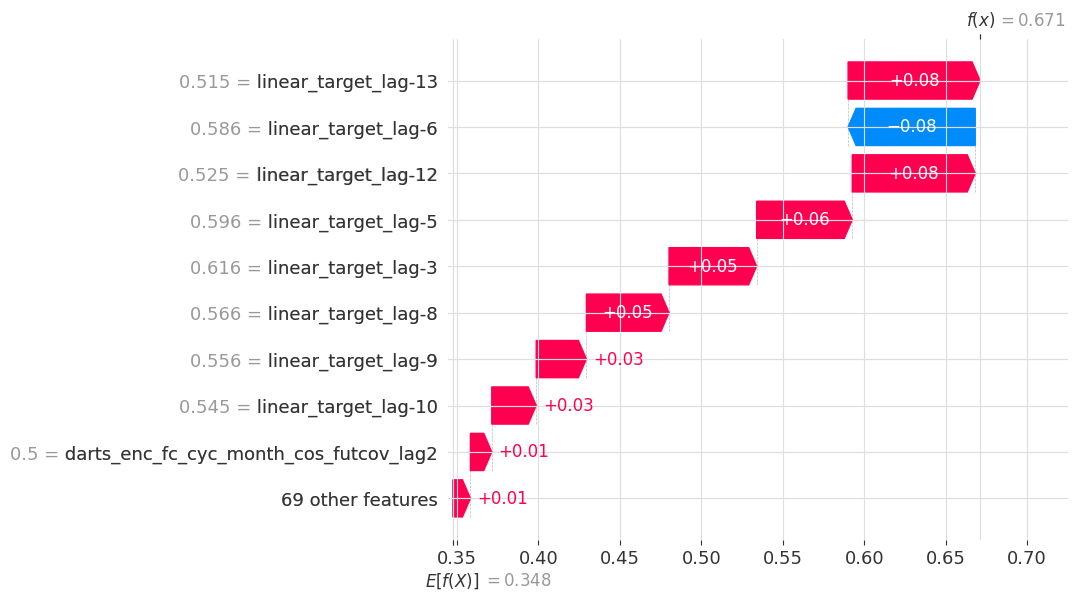

In [20]:
shap.plots.waterfall(
    results.get_shap_explanation_object(horizon=3, component="linear")[-1]
)